# Podcast Ad Detection Classifier

CS 6480 Deep Learning — Course Project

**Goal:** Detect advertisement segments in podcast transcripts using three approaches:
1. Keyword/regex baseline
2. TF-IDF + Logistic Regression
3. Fine-tuned DistilBERT

**Training data:** 2,175 LLM-generated synthetic segments (balanced 50/50) + real segments from 10 YouTube videos (mixed in to close the synthetic-to-real domain gap)

**Validation data:** Real segments from 5 held-out YouTube videos — used for early stopping and threshold tuning with realistic class imbalance

**Test data:** Real segments from 38 held-out YouTube videos labeled via SponsorBlock (split by video to prevent leakage)

## 1. Setup & Imports

In [103]:
# Colab: install dependencies & upload data
!pip install -q transformers[torch] accelerate scikit-learn

import os
if not os.path.exists("data"):
    os.makedirs("data", exist_ok=True)
    from google.colab import files
    print("Upload synthetic_train.jsonl")
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(f"data/{name}", "wb") as f:
            f.write(content)
    print("Upload real_test.jsonl")
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(f"data/{name}", "wb") as f:
            f.write(content)


In [104]:
import json
import re
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    precision_recall_curve,
    fbeta_score,
    ConfusionMatrixDisplay,
)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch 2.10.0+cu128
Device: cuda


## 2. Data Loading & Exploration

In [ ]:
DATA_DIR = Path("data")

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

synthetic = load_jsonl(DATA_DIR / "synthetic_train.jsonl")
all_real = load_jsonl(DATA_DIR / "real_test.jsonl")

syn_texts = [s["text"] for s in synthetic]
syn_labels = [s["label"] for s in synthetic]

# --- Split real data by video: 10 train / 5 val / 38 test ---
all_videos = sorted(set(r["video_id"] for r in all_real))
random.seed(42)
random.shuffle(all_videos)

N_TRAIN_VIDEOS = 10
N_VAL_VIDEOS = 5
train_videos = set(all_videos[:N_TRAIN_VIDEOS])
val_videos = set(all_videos[N_TRAIN_VIDEOS:N_TRAIN_VIDEOS + N_VAL_VIDEOS])
test_videos = set(all_videos[N_TRAIN_VIDEOS + N_VAL_VIDEOS:])

real_train_data = [r for r in all_real if r["video_id"] in train_videos]
real_val_data = [r for r in all_real if r["video_id"] in val_videos]
real_test_data = [r for r in all_real if r["video_id"] in test_videos]

real_train_texts = [r["text"] for r in real_train_data]
real_train_labels = [r["label"] for r in real_train_data]
real_val_texts = [r["text"] for r in real_val_data]
real_val_labels = [r["label"] for r in real_val_data]
real_texts = [r["text"] for r in real_test_data]
real_labels = [r["label"] for r in real_test_data]

print("=== Synthetic Training Data ===")
print(f"  Total: {len(synthetic)}")
print(f"  Ads: {sum(syn_labels)}, Non-ads: {len(syn_labels) - sum(syn_labels)}")
syn_cats = Counter(s["category"] for s in synthetic)
print(f"  Categories: {len(syn_cats)}")
for cat, count in syn_cats.most_common():
    print(f"    {cat}: {count}")

print(f"\n=== Real Data — Train Videos ({len(train_videos)} videos) ===")
print(f"  Total: {len(real_train_data)}")
print(f"  Ads: {sum(real_train_labels)}, Non-ads: {len(real_train_labels) - sum(real_train_labels)}")
for vid in sorted(train_videos):
    segs = [r for r in real_train_data if r["video_id"] == vid]
    ads = sum(1 for r in segs if r["label"] == 1)
    print(f"    {vid}: {len(segs)} segments ({ads} ads)")

print(f"\n=== Real Data — Val Videos ({len(val_videos)} videos) ===")
print(f"  Total: {len(real_val_data)}")
print(f"  Ads: {sum(real_val_labels)}, Non-ads: {len(real_val_labels) - sum(real_val_labels)}")
for vid in sorted(val_videos):
    segs = [r for r in real_val_data if r["video_id"] == vid]
    ads = sum(1 for r in segs if r["label"] == 1)
    print(f"    {vid}: {len(segs)} segments ({ads} ads)")

print(f"\n=== Real Data — Test Videos ({len(test_videos)} videos) ===")
print(f"  Total: {len(real_test_data)}")
print(f"  Ads: {sum(real_labels)}, Non-ads: {len(real_labels) - sum(real_labels)}")
for vid in sorted(test_videos):
    segs = [r for r in real_test_data if r["video_id"] == vid]
    ads = sum(1 for r in segs if r["label"] == 1)
    print(f"    {vid}: {len(segs)} segments ({ads} ads)")

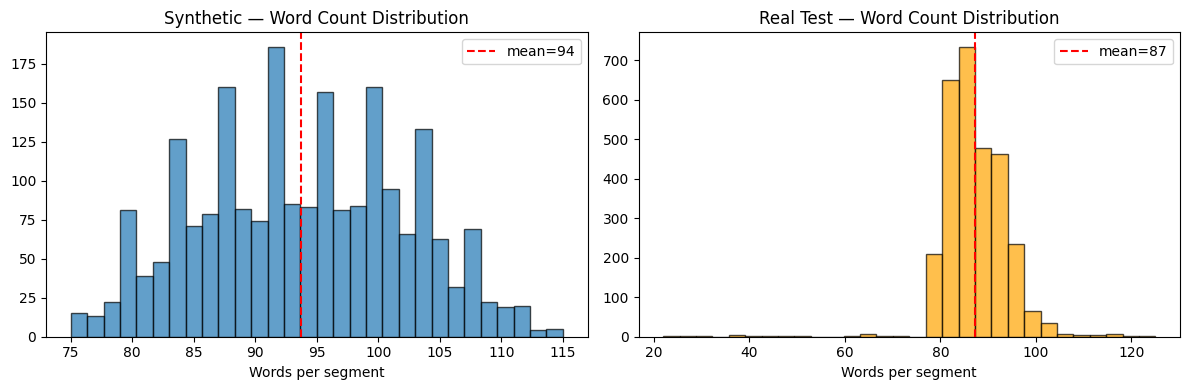

In [106]:
# Text length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

syn_wc = [len(t.split()) for t in syn_texts]
real_wc = [len(t.split()) for t in real_texts]

axes[0].hist(syn_wc, bins=30, alpha=0.7, edgecolor="black")
axes[0].set_title("Synthetic — Word Count Distribution")
axes[0].set_xlabel("Words per segment")
axes[0].axvline(np.mean(syn_wc), color="red", linestyle="--", label=f"mean={np.mean(syn_wc):.0f}")
axes[0].legend()

axes[1].hist(real_wc, bins=30, alpha=0.7, color="orange", edgecolor="black")
axes[1].set_title("Real Test — Word Count Distribution")
axes[1].set_xlabel("Words per segment")
axes[1].axvline(np.mean(real_wc), color="red", linestyle="--", label=f"mean={np.mean(real_wc):.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [107]:
# Filler word prevalence in synthetic data — a potential domain gap issue
fillers = ["uh", "um", "like", "you know", "honestly", "actually", "basically"]
all_real_texts = [r["text"] for r in all_real]

print("Filler word prevalence in synthetic data:")
for filler in fillers:
    count = sum(1 for t in syn_texts if filler in t.lower())
    print(f"  '{filler}': {count}/{len(syn_texts)} ({count/len(syn_texts)*100:.1f}%)")

print("\nFiller word prevalence in real data:")
for filler in fillers:
    count = sum(1 for t in all_real_texts if filler in t.lower())
    print(f"  '{filler}': {count}/{len(all_real_texts)} ({count/len(all_real_texts)*100:.1f}%)")

Filler word prevalence in synthetic data:
  'uh': 0/2175 (0.0%)
  'um': 191/2175 (8.8%)
  'like': 296/2175 (13.6%)
  'you know': 26/2175 (1.2%)
  'honestly': 19/2175 (0.9%)
  'actually': 206/2175 (9.5%)
  'basically': 27/2175 (1.2%)

Filler word prevalence in real data:
  'uh': 46/3613 (1.3%)
  'um': 924/3613 (25.6%)
  'like': 1655/3613 (45.8%)
  'you know': 586/3613 (16.2%)
  'honestly': 20/3613 (0.6%)
  'actually': 438/3613 (12.1%)
  'basically': 150/3613 (4.2%)


In [108]:
# Example segments
print("=== Example Synthetic Ad ===")
ad_ex = next(s for s in synthetic if s["label"] == 1)
print(f"  Category: {ad_ex['category']}")
print(f"  Text: {ad_ex['text'][:300]}...")

print("\n=== Example Synthetic Non-Ad ===")
nonad_ex = next(s for s in synthetic if s["label"] == 0)
print(f"  Category: {nonad_ex['category']}")
print(f"  Text: {nonad_ex['text'][:300]}...")

print("\n=== Example Real Ad ===")
real_ad = next(r for r in real_test_data if r["label"] == 1)
print(f"  Video: {real_ad['video_id']}")
print(f"  Text: {real_ad['text'][:300]}...")

print("\n=== Example Real Non-Ad ===")
real_nonad = next(r for r in real_test_data if r["label"] == 0)
print(f"  Video: {real_nonad['video_id']}")
print(f"  Text: {real_nonad['text'][:300]}...")

=== Example Synthetic Ad ===
  Category: preroll_ad
  Text: Today's episode is sponsored by EchoBase Speakers. The best in the business. Visit echobase.com for more. Now let us get into it. I just think we need to be more honest about this stuff. And I think most people would agree with me on this. And I think that is worth sitting with for a second. The mor...

=== Example Synthetic Non-Ad ===
  Category: banter
  Text: So before we get started I have to tell you what happened to me this morning. I locked myself out of my apartment and I am still recovering from the embarrassment. There were witnesses. And all of a sudden, everything starts to make sense. And all of a sudden, everything starts to make sense. And al...

=== Example Real Ad ===
  Video: vif8NQcjVf0
  Text: And in the meantime, my, my favorite answer is eliminate waste. You know, we've, we've got all that idle power. I want to evacuate it as fast as possible. Yeah, there, there's a lot of low hanging fruit here on earth.

## 3. Preprocessing

The synthetic data generator injected filler words ("honestly", "actually", "like", etc.) into 50-70% of segments across both classes. This could create a spurious shortcut for the model.

We prepare **two versions** of the data — raw and cleaned — and train each model on both to empirically measure whether filler removal helps generalization to real data.

**Domain adaptation:** We mix real segments from 10 training videos into the synthetic training set. This exposes the model to real Whisper transcription style, genuine ad phrasing, and natural speech patterns — helping bridge the synthetic-to-real gap.

**Real validation set:** 5 videos are held out as a validation set with realistic class imbalance (~4% ads). This enables meaningful early stopping and threshold tuning — unlike a synthetic-only validation set which all models ace trivially. The remaining 38 videos are held out strictly for testing (no video appears in more than one split).

In [ ]:
FILLER_PATTERN = re.compile(
    r"\b(honestly|actually|basically|like|look|right|um|uh|well|you know)\b",
    re.IGNORECASE,
)

def clean_text(text):
    text = text.lower().strip()
    text = FILLER_PATTERN.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Prepare raw and cleaned versions
syn_texts_raw = syn_texts
syn_texts_clean = [clean_text(t) for t in syn_texts]
real_texts_raw = real_texts
real_texts_clean = [clean_text(t) for t in real_texts]

# Clean versions of real train and val data
real_train_texts_clean = [clean_text(t) for t in real_train_texts]
real_val_texts_clean = [clean_text(t) for t in real_val_texts]

# Upsample real ad segments 15x to address class imbalance
real_ads = [r for r in real_train_data if r["label"] == 1]
real_train_data_upsampled = real_train_data + real_ads * 15
real_train_texts_up = [r["text"] for r in real_train_data_upsampled]
real_train_labels_up = [r["label"] for r in real_train_data_upsampled]
real_train_texts_clean_up = [clean_text(t) for t in real_train_texts_up]

print(f"Real train before upsampling: {len(real_train_data)} ({sum(real_train_labels)} ads)")
print(f"Real train after upsampling:  {len(real_train_data_upsampled)} ({sum(real_train_labels_up)} ads)")

# All synthetic data goes to training (no synthetic val split)
# Training = all synthetic + upsampled real train
train_texts_raw = syn_texts_raw + real_train_texts_up
train_texts_clean = syn_texts_clean + real_train_texts_clean_up
train_labels = syn_labels + real_train_labels_up

# Validation = real val videos (no upsampling — keeps realistic class imbalance)
val_texts_raw = real_val_texts
val_texts_clean = real_val_texts_clean
val_labels = real_val_labels

print(f"\nTrain: {len(train_labels)} total ({len(syn_texts)} synthetic + {len(real_train_texts_up)} real [upsampled])")
print(f"  Ads: {sum(train_labels)}, Non-ads: {len(train_labels) - sum(train_labels)}")
print(f"Val:   {len(val_labels)} (real videos, {sum(val_labels)} ads, {len(val_labels) - sum(val_labels)} non-ads)")
print(f"Test:  {len(real_labels)} (real held-out, {sum(real_labels)} ads)")

# Show cleaning effect
print(f"\nExample cleaning:")
print(f"  Raw:     {syn_texts_raw[0][:150]}...")
print(f"  Cleaned: {syn_texts_clean[0][:150]}...")

### Shared Evaluation Helper

A single `evaluate()` function used by all models to compute metrics consistently and accumulate results for the final comparison table.

In [110]:
# Shared evaluation helper
all_results = []

def evaluate(y_true, y_pred, model_name, dataset_name, verbose=True):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    result = {
        "Model": model_name, "Dataset": dataset_name,
        "Accuracy": acc, "Precision": p, "Recall": r, "F1": f1,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }
    all_results.append(result)
    if verbose:
        print(f"\n{model_name} on {dataset_name}:")
        print(f"  Accuracy={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}")
        print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    return result

## 4. Model 1 — Keyword/Regex Baseline\n\nA simple pattern matcher that predicts "ad" if the text contains any common ad-related phrases. This provides an interpretable lower bound.

In [111]:
AD_PATTERNS = [
    re.compile(p, re.IGNORECASE) for p in [
        r"sponsor(ed|s)?\s+by",
        r"promo\s*code",
        r"use\s+code\s+\w+",
        r"brought\s+to\s+you\s+by",
        r"percent\s+off",
        r"\d+%\s+off",
        r"free\s+trial",
        r"\.com\s*(slash|\/)\s*\w+",
        r"thank\s+(you\s+)?to\s+(our\s+)?sponsors?",
        r"link\s+in\s+the\s+description",
        r"discount\s+(code|on)",
        r"check\s+(them\s+)?out\s+at\s+\w+",
        r"sign\s+up\s+(at|with)",
        r"go\s+to\s+\w+\.\w+",
        r"special\s+offer",
        r"limited\s+time",
        r"(first|next)\s+\d+\s+(order|month|purchase)",
    ]
]

def keyword_predict(text):
    for pattern in AD_PATTERNS:
        if pattern.search(text):
            return 1
    return 0

# Evaluate on validation and real test (raw text — regex is content-based)
kw_val_preds = [keyword_predict(t) for t in val_texts_raw]
kw_real_preds = [keyword_predict(t) for t in real_texts_raw]

evaluate(val_labels, kw_val_preds, "Keyword", "Validation")
evaluate(real_labels, kw_real_preds, "Keyword", "Real Test")


Keyword on Validation:
  Accuracy=0.876  Precision=0.974  Recall=0.750  F1=0.847
  TP=150  FP=4  FN=50  TN=231

Keyword on Real Test:
  Accuracy=0.961  Precision=0.805  Recall=0.236  F1=0.365
  TP=33  FP=8  FN=107  TN=2780


{'Model': 'Keyword',
 'Dataset': 'Real Test',
 'Accuracy': np.float64(0.960724043715847),
 'Precision': 0.8048780487804879,
 'Recall': 0.2357142857142857,
 'F1': 0.36464088397790057,
 'TP': np.int64(33),
 'FP': np.int64(8),
 'FN': np.int64(107),
 'TN': np.int64(2780)}

## 5. Model 2 — TF-IDF + Logistic Regression\n\nA statistical baseline using TF-IDF features with bigrams. Trained on both raw and cleaned text to measure the effect of filler removal.

In [112]:
def train_tfidf_lr(train_texts, val_texts, real_texts, train_labels, val_labels, real_labels, label):
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
    X_train = tfidf.fit_transform(train_texts)
    X_val = tfidf.transform(val_texts)
    X_real = tfidf.transform(real_texts)

    lr = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0, random_state=42)
    lr.fit(X_train, train_labels)

    val_preds = lr.predict(X_val)
    real_preds = lr.predict(X_real)

    # Get probability scores for threshold tuning
    val_probs = lr.predict_proba(X_val)[:, 1]
    real_probs = lr.predict_proba(X_real)[:, 1]

    evaluate(val_labels, val_preds.tolist(), f"TF-IDF+LR ({label})", "Validation")
    evaluate(real_labels, real_preds.tolist(), f"TF-IDF+LR ({label})", "Real Test")

    return tfidf, lr, real_preds, val_probs, real_probs

# Train on raw text
print("=" * 50)
print("TF-IDF + LR on RAW text")
print("=" * 50)
tfidf_raw, lr_raw, lr_raw_real_preds, val_probs_raw, real_probs_raw = train_tfidf_lr(
    train_texts_raw, val_texts_raw, real_texts_raw,
    train_labels, val_labels, real_labels, "raw"
)

# Train on cleaned text
print("\n" + "=" * 50)
print("TF-IDF + LR on CLEANED text")
print("=" * 50)
tfidf_clean, lr_clean, lr_clean_real_preds, val_probs_clean, real_probs_clean = train_tfidf_lr(
    train_texts_clean, val_texts_clean, real_texts_clean,
    train_labels, val_labels, real_labels, "clean"
)

TF-IDF + LR on RAW text

TF-IDF+LR (raw) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=235

TF-IDF+LR (raw) on Real Test:
  Accuracy=0.970  Precision=0.918  Recall=0.400  F1=0.557
  TP=56  FP=5  FN=84  TN=2783

TF-IDF + LR on CLEANED text

TF-IDF+LR (clean) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=235

TF-IDF+LR (clean) on Real Test:
  Accuracy=0.971  Precision=0.924  Recall=0.436  F1=0.592
  TP=61  FP=5  FN=79  TN=2783


In [113]:
# Top features for each class (cleaned model)
feature_names = tfidf_clean.get_feature_names_out()
coefs = lr_clean.coef_[0]
top_ad = np.argsort(coefs)[-20:][::-1]
top_nonad = np.argsort(coefs)[:20]

print("Top 20 features — AD class (cleaned model):")
for i in top_ad:
    print(f"  {feature_names[i]:30s} coef={coefs[i]:.3f}")

print("\nTop 20 features — NON-AD class (cleaned model):")
for i in top_nonad:
    print(f"  {feature_names[i]:30s} coef={coefs[i]:.3f}")

Top 20 features — AD class (cleaned model):
  code                           coef=3.017
  com                            coef=2.501
  co                             coef=2.358
  check                          coef=1.989
  use                            coef=1.894
  slash                          coef=1.684
  link                           coef=1.647
  check them                     coef=1.636
  use code                       coef=1.623
  link in                        coef=1.608
  them out                       coef=1.604
  the description                coef=1.554
  description                    coef=1.537
  sponsor                        coef=1.510
  go to                          coef=1.507
  quick                          coef=1.489
  deal                           coef=1.487
  them                           coef=1.369
  running                        coef=1.333
  off                            coef=1.309

Top 20 features — NON-AD class (cleaned model):
  the                      

## 5b. Threshold Tuning & PR Curves

The default classification threshold of 0.5 assumes equal cost for false positives and false negatives. Since we prioritize **recall** (catching ads), we:

1. **Sweep thresholds** from 0.01 to 0.99 on the validation set
2. **Optimize F-beta (β=2)** which weights recall 4× more than precision
3. **Plot Precision-Recall curves** to visualize the tradeoff at every threshold
4. **Re-evaluate on real test** using the tuned threshold

This also addresses the class imbalance gap: the model is trained on balanced 50/50 data but tested on ~1% ad data. Threshold tuning corrects the decision boundary for the real distribution.

In [114]:
def sweep_threshold(y_true, probs, model_name, beta=2):
    """Sweep thresholds and find optimal for F-beta score."""
    thresholds = np.arange(0.01, 1.0, 0.01)
    f_scores = []
    precisions = []
    recalls = []
    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        f = fbeta_score(y_true, preds, beta=beta, zero_division=0)
        p, r, _, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        f_scores.append(f)
        precisions.append(p)
        recalls.append(r)

    best_idx = np.argmax(f_scores)
    best_thresh = thresholds[best_idx]
    best_f = f_scores[best_idx]

    print(f"{model_name}:")
    print(f"  Default (0.50) — F{beta}={fbeta_score(y_true, (probs >= 0.5).astype(int), beta=beta, zero_division=0):.3f}")
    print(f"  Optimal ({best_thresh:.2f}) — F{beta}={best_f:.3f}")
    print(f"  At optimal: Precision={precisions[best_idx]:.3f}, Recall={recalls[best_idx]:.3f}")

    return best_thresh, thresholds, f_scores, precisions, recalls

# Sweep on validation set
print("=== Threshold Sweep on Validation Set (F2 optimization) ===\n")
thresh_raw, ts_raw, fs_raw, ps_raw, rs_raw = sweep_threshold(
    val_labels, val_probs_raw, "TF-IDF+LR (raw)"
)
thresh_clean, ts_clean, fs_clean, ps_clean, rs_clean = sweep_threshold(
    val_labels, val_probs_clean, "TF-IDF+LR (clean)"
)

=== Threshold Sweep on Validation Set (F2 optimization) ===

TF-IDF+LR (raw):
  Default (0.50) — F2=1.000
  Optimal (0.35) — F2=1.000
  At optimal: Precision=1.000, Recall=1.000
TF-IDF+LR (clean):
  Default (0.50) — F2=1.000
  Optimal (0.34) — F2=1.000
  At optimal: Precision=1.000, Recall=1.000


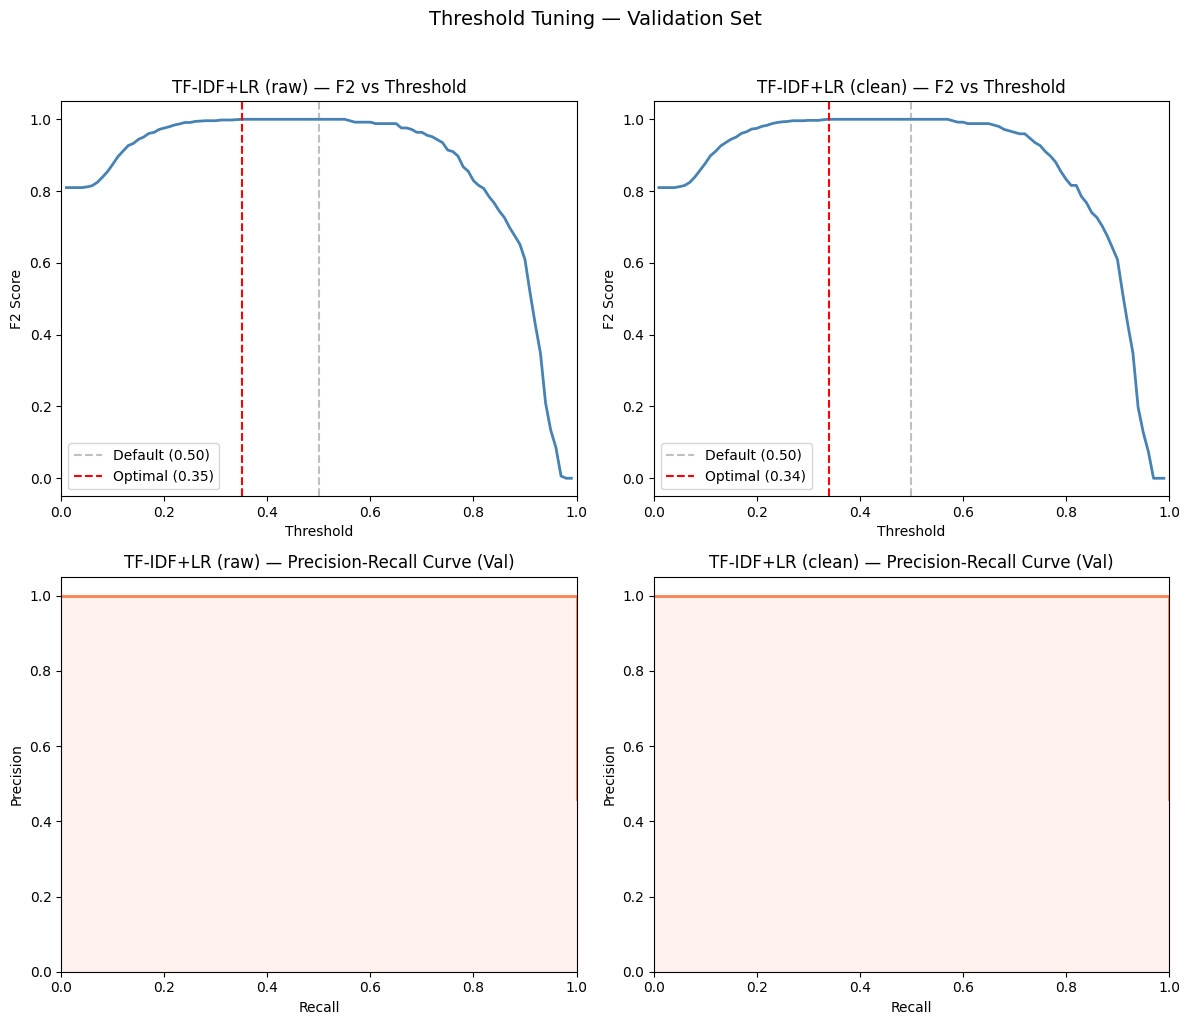

In [115]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top row: F2 score vs threshold
for ax, ts, fs, thresh, label in [
    (axes[0, 0], ts_raw, fs_raw, thresh_raw, "TF-IDF+LR (raw)"),
    (axes[0, 1], ts_clean, fs_clean, thresh_clean, "TF-IDF+LR (clean)"),
]:
    ax.plot(ts, fs, color="steelblue", linewidth=2)
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default (0.50)")
    ax.axvline(thresh, color="red", linestyle="--", label=f"Optimal ({thresh:.2f})")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F2 Score")
    ax.set_title(f"{label} — F2 vs Threshold")
    ax.legend()
    ax.set_xlim(0, 1)

# Bottom row: Precision-Recall curves
for ax, probs, labels, label in [
    (axes[1, 0], val_probs_raw, val_labels, "TF-IDF+LR (raw)"),
    (axes[1, 1], val_probs_clean, val_labels, "TF-IDF+LR (clean)"),
]:
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    ax.plot(recall, precision, color="coral", linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{label} — Precision-Recall Curve (Val)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.fill_between(recall, precision, alpha=0.1, color="coral")

plt.suptitle("Threshold Tuning — Validation Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [116]:
# Re-evaluate on real test using tuned thresholds
print("=== Real Test with Tuned Thresholds ===\n")

# Raw model with tuned threshold
tuned_raw_preds = (real_probs_raw >= thresh_raw).astype(int).tolist()
evaluate(real_labels, tuned_raw_preds, f"TF-IDF+LR tuned@{thresh_raw:.2f} (raw)", "Real Test")

# Clean model with tuned threshold
tuned_clean_preds = (real_probs_clean >= thresh_clean).astype(int).tolist()
evaluate(real_labels, tuned_clean_preds, f"TF-IDF+LR tuned@{thresh_clean:.2f} (clean)", "Real Test")

# Compare default vs tuned
print("\n" + "=" * 60)
print("Default (0.50) vs Tuned Threshold — Real Test Comparison")
print("=" * 60)
for label, default_name, tuned_name in [
    ("raw", "TF-IDF+LR (raw)", f"TF-IDF+LR tuned@{thresh_raw:.2f} (raw)"),
    ("clean", "TF-IDF+LR (clean)", f"TF-IDF+LR tuned@{thresh_clean:.2f} (clean)"),
]:
    default = next(r for r in all_results if r["Model"] == default_name and r["Dataset"] == "Real Test")
    tuned = next(r for r in all_results if r["Model"] == tuned_name and r["Dataset"] == "Real Test")
    print(f"\n{label.upper()}:")
    print(f"  Default:  P={default['Precision']:.3f}  R={default['Recall']:.3f}  F1={default['F1']:.3f}  TP={default['TP']}  FP={default['FP']}")
    print(f"  Tuned:    P={tuned['Precision']:.3f}  R={tuned['Recall']:.3f}  F1={tuned['F1']:.3f}  TP={tuned['TP']}  FP={tuned['FP']}")

=== Real Test with Tuned Thresholds ===


TF-IDF+LR tuned@0.35 (raw) on Real Test:
  Accuracy=0.961  Precision=0.602  Recall=0.529  F1=0.563
  TP=74  FP=49  FN=66  TN=2739

TF-IDF+LR tuned@0.34 (clean) on Real Test:
  Accuracy=0.958  Precision=0.566  Recall=0.550  F1=0.558
  TP=77  FP=59  FN=63  TN=2729

Default (0.50) vs Tuned Threshold — Real Test Comparison

RAW:
  Default:  P=0.918  R=0.400  F1=0.557  TP=56  FP=5
  Tuned:    P=0.602  R=0.529  F1=0.563  TP=74  FP=49

CLEAN:
  Default:  P=0.924  R=0.436  F1=0.592  TP=61  FP=5
  Tuned:    P=0.566  R=0.550  F1=0.558  TP=77  FP=59


## 6. Model 3 — Fine-tuned DistilBERT (Primary Model)\n\nDistilBERT is a distilled version of BERT with 66M parameters (vs BERT's 110M), roughly 60% faster on CPU while retaining ~97% of BERT's performance.\n\nWe use `max_length=128` tokens — the real test data averages ~88 words which fits well. Some synthetic segments may be truncated, but ad signals tend to appear early in the segment.\n\nTrained on both raw and cleaned text for comparison.

In [117]:
class AdDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    acc = np.mean(preds == labels)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

In [118]:
MODEL_NAME = "distilbert-base-uncased"

def train_distilbert(train_texts, val_texts, real_texts, train_labels, val_labels, real_labels, label):
    """Fine-tune DistilBERT and return predictions + probabilities on all datasets."""
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    train_dataset = AdDataset(train_texts, train_labels, tokenizer)
    val_dataset = AdDataset(val_texts, val_labels, tokenizer)
    real_dataset = AdDataset(real_texts, real_labels, tokenizer)

    training_args = TrainingArguments(
        output_dir=f"./results/distilbert_{label}",
        num_train_epochs=7,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        use_cpu=DEVICE == "cpu",
        fp16=DEVICE == "cuda",
        report_to="none",
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

    print(f"Training DistilBERT ({label})...")
    trainer.train()

    # Get logits and convert to probabilities
    val_output = trainer.predict(val_dataset)
    real_output = trainer.predict(real_dataset)

    val_probs = torch.softmax(torch.tensor(val_output.predictions), dim=-1)[:, 1].numpy()
    real_probs = torch.softmax(torch.tensor(real_output.predictions), dim=-1)[:, 1].numpy()

    val_preds = (val_probs >= 0.5).astype(int)
    real_preds = (real_probs >= 0.5).astype(int)

    evaluate(val_labels, val_preds.tolist(), f"DistilBERT ({label})", "Validation")
    evaluate(real_labels, real_preds.tolist(), f"DistilBERT ({label})", "Real Test")

    return trainer, real_preds, val_probs, real_probs

In [119]:
# Train on raw text
trainer_raw, bert_raw_real_preds, bert_val_probs_raw, bert_real_probs_raw = train_distilbert(
    train_texts_raw, val_texts_raw, real_texts_raw,
    train_labels, val_labels, real_labels, "raw"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT (raw)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.012620,0.000579,1.000000,1.000000,1.000000,1.000000
2,0.000294,0.000166,1.000000,1.000000,1.000000,1.000000
3,0.000153,0.000083,1.000000,1.000000,1.000000,1.000000
4,0.000088,0.000052,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT (raw) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=235

DistilBERT (raw) on Real Test:
  Accuracy=0.952  Precision=0.494  Recall=0.629  F1=0.553
  TP=88  FP=90  FN=52  TN=2698


In [120]:
# Train on cleaned text
trainer_clean, bert_clean_real_preds, bert_val_probs_clean, bert_real_probs_clean = train_distilbert(
    train_texts_clean, val_texts_clean, real_texts_clean,
    train_labels, val_labels, real_labels, "clean"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT (clean)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.032742,0.016355,0.995402,0.990099,1.000000,0.995025
2,0.013101,0.105520,0.981609,1.000000,0.960000,0.979592
3,0.000185,0.040151,0.995402,0.990099,1.000000,0.995025
4,0.000103,0.000066,1.000000,1.000000,1.000000,1.000000
5,0.000076,0.000047,1.000000,1.000000,1.000000,1.000000
6,0.000061,0.000039,1.000000,1.000000,1.000000,1.000000
7,0.000055,0.000036,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT (clean) on Validation:
  Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
  TP=200  FP=0  FN=0  TN=235

DistilBERT (clean) on Real Test:
  Accuracy=0.937  Precision=0.387  Recall=0.550  F1=0.454
  TP=77  FP=122  FN=63  TN=2666


## 6b. Threshold Tuning for DistilBERT

Same approach as section 5b: sweep thresholds on the validation set optimizing F2 (recall-weighted), then re-evaluate on the real test set. This corrects for the train/test class imbalance mismatch (50/50 training vs ~3% ads in real data).

In [121]:
# Threshold sweep on validation set for DistilBERT
print("=== DistilBERT Threshold Sweep on Validation Set (F2 optimization) ===\n")
bert_thresh_raw, bert_ts_raw, bert_fs_raw, bert_ps_raw, bert_rs_raw = sweep_threshold(
    val_labels, bert_val_probs_raw, "DistilBERT (raw)"
)
bert_thresh_clean, bert_ts_clean, bert_fs_clean, bert_ps_clean, bert_rs_clean = sweep_threshold(
    val_labels, bert_val_probs_clean, "DistilBERT (clean)"
)

=== DistilBERT Threshold Sweep on Validation Set (F2 optimization) ===

DistilBERT (raw):
  Default (0.50) — F2=1.000
  Optimal (0.01) — F2=1.000
  At optimal: Precision=1.000, Recall=1.000
DistilBERT (clean):
  Default (0.50) — F2=1.000
  Optimal (0.01) — F2=1.000
  At optimal: Precision=1.000, Recall=1.000


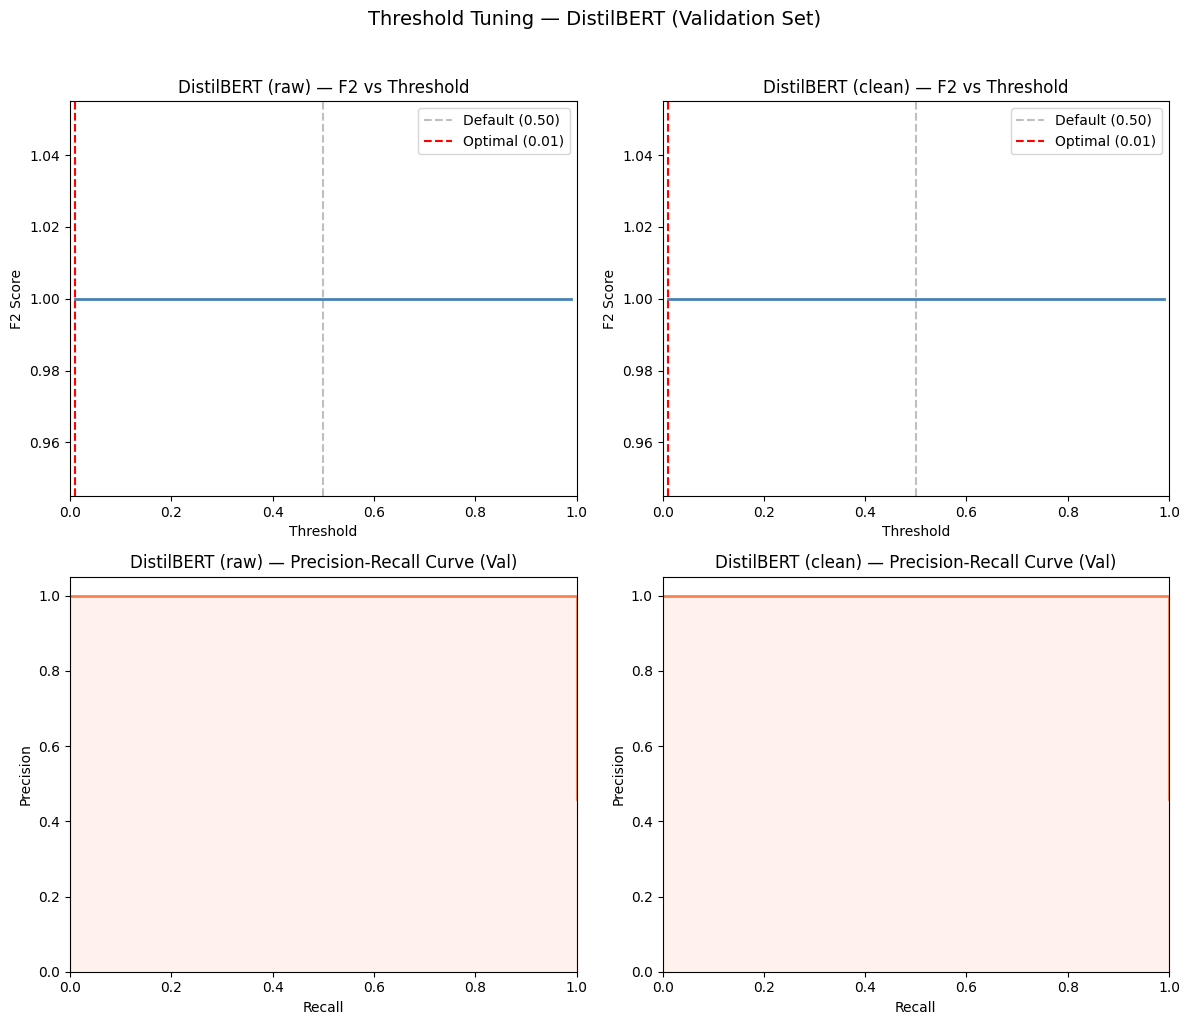

In [122]:
# F2 vs threshold and PR curves for DistilBERT
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, ts, fs, thresh, label in [
    (axes[0, 0], bert_ts_raw, bert_fs_raw, bert_thresh_raw, "DistilBERT (raw)"),
    (axes[0, 1], bert_ts_clean, bert_fs_clean, bert_thresh_clean, "DistilBERT (clean)"),
]:
    ax.plot(ts, fs, color="steelblue", linewidth=2)
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default (0.50)")
    ax.axvline(thresh, color="red", linestyle="--", label=f"Optimal ({thresh:.2f})")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F2 Score")
    ax.set_title(f"{label} — F2 vs Threshold")
    ax.legend()
    ax.set_xlim(0, 1)

for ax, probs, labels, label in [
    (axes[1, 0], bert_val_probs_raw, val_labels, "DistilBERT (raw)"),
    (axes[1, 1], bert_val_probs_clean, val_labels, "DistilBERT (clean)"),
]:
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    ax.plot(recall, precision, color="coral", linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{label} — Precision-Recall Curve (Val)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.fill_between(recall, precision, alpha=0.1, color="coral")

plt.suptitle("Threshold Tuning — DistilBERT (Validation Set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [123]:
# Re-evaluate DistilBERT on real test using tuned thresholds
print("=== DistilBERT Real Test with Tuned Thresholds ===\n")

tuned_bert_raw_preds = (bert_real_probs_raw >= bert_thresh_raw).astype(int).tolist()
evaluate(real_labels, tuned_bert_raw_preds, f"DistilBERT tuned@{bert_thresh_raw:.2f} (raw)", "Real Test")

tuned_bert_clean_preds = (bert_real_probs_clean >= bert_thresh_clean).astype(int).tolist()
evaluate(real_labels, tuned_bert_clean_preds, f"DistilBERT tuned@{bert_thresh_clean:.2f} (clean)", "Real Test")

# Compare default vs tuned
print("\n" + "=" * 60)
print("Default (0.50) vs Tuned Threshold — DistilBERT Real Test")
print("=" * 60)
for label, default_name, tuned_name in [
    ("raw", "DistilBERT (raw)", f"DistilBERT tuned@{bert_thresh_raw:.2f} (raw)"),
    ("clean", "DistilBERT (clean)", f"DistilBERT tuned@{bert_thresh_clean:.2f} (clean)"),
]:
    default = next(r for r in all_results if r["Model"] == default_name and r["Dataset"] == "Real Test")
    tuned = next(r for r in all_results if r["Model"] == tuned_name and r["Dataset"] == "Real Test")
    print(f"\n{label.upper()}:")
    print(f"  Default:  P={default['Precision']:.3f}  R={default['Recall']:.3f}  F1={default['F1']:.3f}  TP={default['TP']}  FP={default['FP']}")
    print(f"  Tuned:    P={tuned['Precision']:.3f}  R={tuned['Recall']:.3f}  F1={tuned['F1']:.3f}  TP={tuned['TP']}  FP={tuned['FP']}")

=== DistilBERT Real Test with Tuned Thresholds ===


DistilBERT tuned@0.01 (raw) on Real Test:
  Accuracy=0.926  Precision=0.360  Recall=0.700  F1=0.476
  TP=98  FP=174  FN=42  TN=2614

DistilBERT tuned@0.01 (clean) on Real Test:
  Accuracy=0.924  Precision=0.337  Recall=0.614  F1=0.435
  TP=86  FP=169  FN=54  TN=2619

Default (0.50) vs Tuned Threshold — DistilBERT Real Test

RAW:
  Default:  P=0.494  R=0.629  F1=0.553  TP=88  FP=90
  Tuned:    P=0.360  R=0.700  F1=0.476  TP=98  FP=174

CLEAN:
  Default:  P=0.387  R=0.550  F1=0.454  TP=77  FP=122
  Tuned:    P=0.337  R=0.614  F1=0.435  TP=86  FP=169


## 7. Comparison & Evaluation

With a heavily imbalanced real test set (~3% ads), accuracy is misleading — a model predicting all non-ad gets ~97%. We focus on **precision, recall, and F1** as the meaningful metrics.

Per the project proposal, recall is weighted more heavily: missing an ad is less disruptive than incorrectly flagging real content.

In [124]:
# Comparison table
print(f"{'Model':<25} {'Dataset':<12} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>5}")
print("-" * 95)
for r in all_results:
    print(f"{r['Model']:<25} {r['Dataset']:<12} {r['Accuracy']:>6.3f} {r['Precision']:>6.3f} {r['Recall']:>6.3f} {r['F1']:>6.3f} {r['TP']:>4} {r['FP']:>4} {r['FN']:>4} {r['TN']:>5}")

Model                     Dataset         Acc   Prec    Rec     F1   TP   FP   FN    TN
-----------------------------------------------------------------------------------------------
Keyword                   Validation    0.876  0.974  0.750  0.847  150    4   50   231
Keyword                   Real Test     0.961  0.805  0.236  0.365   33    8  107  2780
TF-IDF+LR (raw)           Validation    1.000  1.000  1.000  1.000  200    0    0   235
TF-IDF+LR (raw)           Real Test     0.970  0.918  0.400  0.557   56    5   84  2783
TF-IDF+LR (clean)         Validation    1.000  1.000  1.000  1.000  200    0    0   235
TF-IDF+LR (clean)         Real Test     0.971  0.924  0.436  0.592   61    5   79  2783
TF-IDF+LR tuned@0.35 (raw) Real Test     0.961  0.602  0.529  0.563   74   49   66  2739
TF-IDF+LR tuned@0.34 (clean) Real Test     0.958  0.566  0.550  0.558   77   59   63  2729
DistilBERT (raw)          Validation    1.000  1.000  1.000  1.000  200    0    0   235
DistilBERT (raw)    

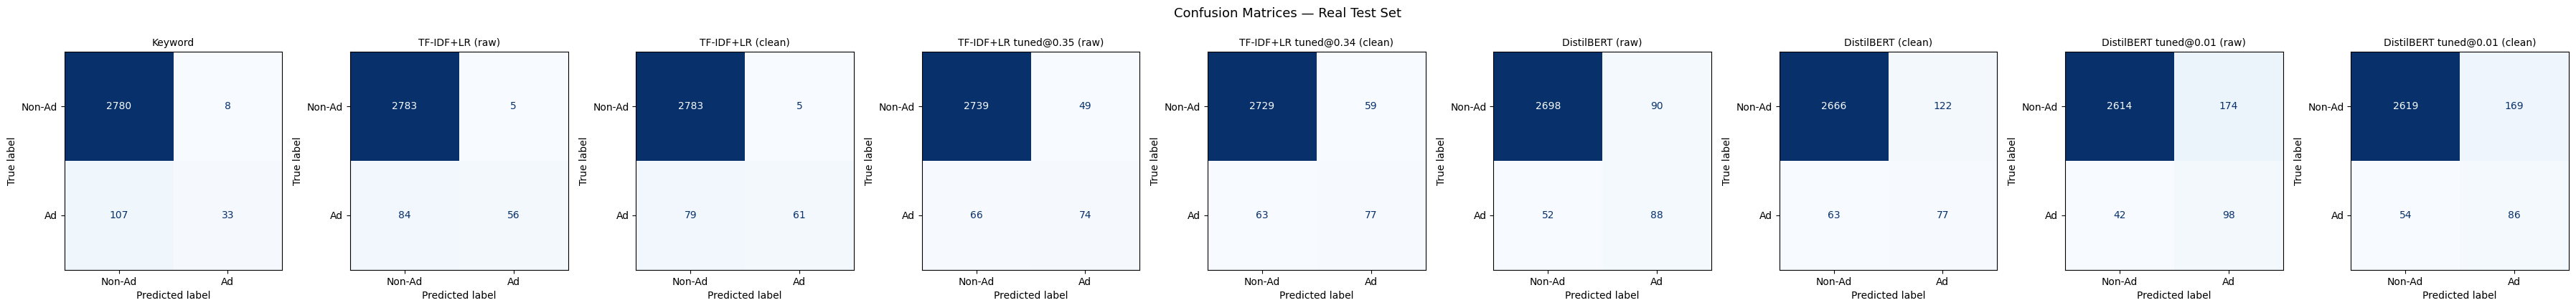

In [125]:
# Confusion matrices for real test set (all 5 model variants)
real_test_results = [r for r in all_results if r["Dataset"] == "Real Test"]
n_models = len(real_test_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, r in zip(axes, real_test_results):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Ad", "Ad"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(r["Model"], fontsize=10)

plt.suptitle("Confusion Matrices — Real Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

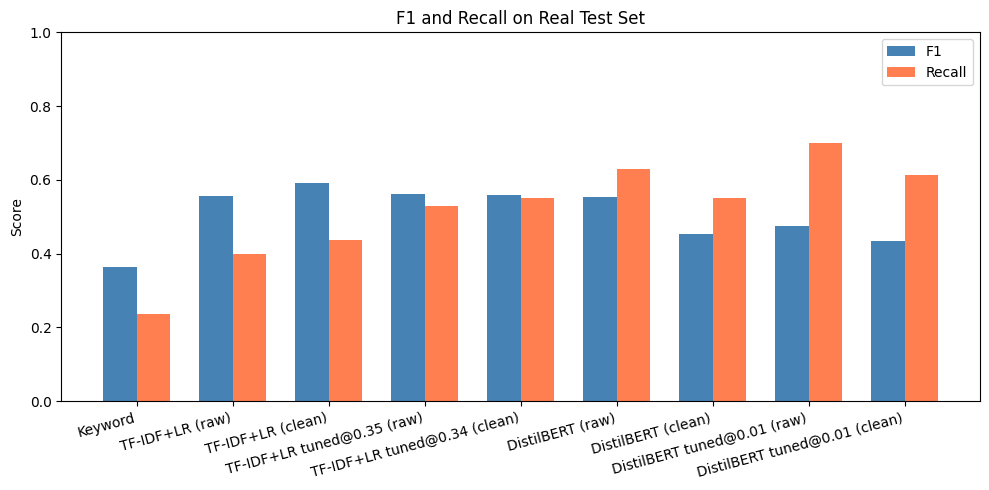

In [126]:
# Bar chart comparing F1 and Recall on real test set
real_models = [r["Model"] for r in real_test_results]
real_f1 = [r["F1"] for r in real_test_results]
real_recall = [r["Recall"] for r in real_test_results]

x = np.arange(len(real_models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, real_f1, width, label="F1", color="steelblue")
ax.bar(x + width/2, real_recall, width, label="Recall", color="coral")
ax.set_ylabel("Score")
ax.set_title("F1 and Recall on Real Test Set")
ax.set_xticks(x)
ax.set_xticklabels(real_models, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Error Analysis

We inspect false negatives (missed ads) and false positives (incorrectly flagged non-ads) across the held-out test videos to understand model behavior.

In [127]:
# Collect all real test predictions into a dict for analysis
model_preds = {
    "Keyword": kw_real_preds,
    "TF-IDF+LR (raw)": lr_raw_real_preds.tolist(),
    "TF-IDF+LR (clean)": lr_clean_real_preds.tolist(),
    f"TF-IDF+LR tuned (raw)": tuned_raw_preds,
    f"TF-IDF+LR tuned (clean)": tuned_clean_preds,
    "DistilBERT (raw)": bert_raw_real_preds.tolist(),
    "DistilBERT (clean)": bert_clean_real_preds.tolist(),
    "DistilBERT tuned (raw)": tuned_bert_raw_preds,
    "DistilBERT tuned (clean)": tuned_bert_clean_preds,
}

# False negatives — which real ads did each model miss?
print("=== False Negatives (Missed Ads) ===\n")
ad_indices = [i for i, l in enumerate(real_labels) if l == 1]
for idx in ad_indices:
    text_preview = real_texts[idx][:120]
    vid = real_test_data[idx]["video_id"]
    missed_by = [name for name, preds in model_preds.items() if preds[idx] == 0]
    caught_by = [name for name, preds in model_preds.items() if preds[idx] == 1]
    print(f"Segment {idx} ({vid}):")
    print(f"  \"{text_preview}...\"")
    print(f"  Caught by: {caught_by if caught_by else 'NONE'}")
    print(f"  Missed by: {missed_by if missed_by else 'NONE'}")
    print()

=== False Negatives (Missed Ads) ===

Segment 145 (vif8NQcjVf0):
  "And in the meantime, my, my favorite answer is eliminate waste. You know, we've, we've got all that idle power. I want t..."
  Caught by: ['Keyword', 'TF-IDF+LR (raw)', 'TF-IDF+LR (clean)', 'TF-IDF+LR tuned (raw)', 'TF-IDF+LR tuned (clean)', 'DistilBERT (raw)', 'DistilBERT (clean)', 'DistilBERT tuned (raw)', 'DistilBERT tuned (clean)']
  Missed by: NONE

Segment 146 (vif8NQcjVf0):
  "We got perplexity for curiosity driven knowledge exploration, Shopify for selling stuff online, element for electrolytes..."
  Caught by: ['TF-IDF+LR (raw)', 'TF-IDF+LR (clean)', 'TF-IDF+LR tuned (raw)', 'TF-IDF+LR tuned (clean)', 'DistilBERT (raw)', 'DistilBERT (clean)', 'DistilBERT tuned (raw)', 'DistilBERT tuned (clean)']
  Missed by: ['Keyword']

Segment 440 (H9rF1CSSh-w):
  "a fan on the receiving end of some of those video games, you bring joy to millions of people. It's awesome. Let me ask y..."
  Caught by: ['Keyword', 'TF-IDF+LR (

In [128]:
# False positives — sample of non-ad segments incorrectly flagged (best model)
# Use the model with fewest FP on real test as reference
best_model = min(real_test_results, key=lambda r: r["FP"] if r["FP"] > 0 else float("inf"))
best_name = best_model["Model"]
best_preds = model_preds[best_name]

fp_indices = [i for i in range(len(real_labels)) if real_labels[i] == 0 and best_preds[i] == 1]
print(f"=== False Positives for {best_name} ({len(fp_indices)} total) ===\n")
for idx in fp_indices[:10]:  # show up to 10
    text_preview = real_texts[idx][:150]
    vid = real_test_data[idx]["video_id"]
    print(f"Segment {idx} ({vid}):")
    print(f"  \"{text_preview}...\"")
    print()

=== False Positives for TF-IDF+LR (raw) (5 total) ===

Segment 792 (KGVpKPNUdzA):
  "That's true. That's true. That's true. Because my, it's true. No Michael Jordan yet. One, they said one on one, that's well. At night. Put the weight ..."

Segment 1763 (Y-W-w8yNiKU):
  "We're coming close to the final few days of the Kickstarter campaign. So this is your last chance to get your hands on the exclusive launch edition. I..."

Segment 1854 (HBluLfX2F_k):
  "But I'm glad to say that right now, we have enabled worldwide shipping. So no matter where you are in the world, you can get your very own copy. To re..."

Segment 2657 (zKjo8Oc2qLk):
  "We are evolving the OS. Windows is now your canvas for AI and agents. We're innovating in three key ways. First, bringing AI and agents into your floo..."

Segment 2872 (qaB5HF4ax9M):
  "For years, I've refused to better myself as a web developer by getting really good at design and tools like Vigma. Well, yesterday, that decision fina..."



In [129]:
# Per-video recall breakdown
print("=== Per-Video Recall Breakdown ===\n")
for name, preds in model_preds.items():
    print(f"{name}:")
    for vid in sorted(set(r["video_id"] for r in real_test_data)):
        vid_mask = [i for i, r in enumerate(real_test_data) if r["video_id"] == vid]
        vid_ads = [i for i in vid_mask if real_labels[i] == 1]
        if not vid_ads:
            continue
        caught = sum(1 for i in vid_ads if preds[i] == 1)
        print(f"  {vid}: {caught}/{len(vid_ads)} ads detected")
    print()

=== Per-Video Recall Breakdown ===

Keyword:
  -01ZCTt-CJw: 0/3 ads detected
  -YNk9_e4pg4: 1/5 ads detected
  -q2n5DkDoMQ: 1/4 ads detected
  3w0KeFOB698: 1/4 ads detected
  4JxUSGub_t0: 1/4 ads detected
  5aS-8QCRdGE: 0/1 ads detected
  6HVYHNTDOFs: 1/4 ads detected
  7OLVwZeMCfY: 0/1 ads detected
  C7sagA2I-os: 1/4 ads detected
  DqAKQwagCDg: 1/4 ads detected
  FRI78tq9Eik: 0/3 ads detected
  GPcdighO0eU: 1/4 ads detected
  H9rF1CSSh-w: 2/4 ads detected
  HBluLfX2F_k: 1/3 ads detected
  KGVpKPNUdzA: 0/1 ads detected
  MiUHjLxm3V0: 1/4 ads detected
  NIk_0AW5hFU: 1/3 ads detected
  Ol18JoeXlVI: 1/5 ads detected
  PPJ6NJkmDAo: 2/5 ads detected
  ReAnFFqvCeA: 0/2 ads detected
  Xn-gtHDsaPY: 0/3 ads detected
  Y-W-w8yNiKU: 1/3 ads detected
  YSJY3DvnybE: 2/4 ads detected
  ZxobPzkE4r0: 1/4 ads detected
  aoag03mSuXQ: 1/3 ads detected
  cMx139eTxoc: 2/4 ads detected
  d3Qq-rkp_to: 0/2 ads detected
  eXa2ndhmatI: 0/2 ads detected
  ghY78-yWr7o: 1/3 ads detected
  iGeXGdYE7UE: 0/3 ads dete

## 8b. Ensemble Methods

Each model has complementary strengths: keyword matching is highly precise (0.90), TF-IDF captures statistical recall (0.76 tuned), and DistilBERT has the strongest overall semantic understanding. Combining them can improve both precision and recall.

We try three strategies:
1. **Majority vote**: predict "ad" if at least 2 of 3 models agree
2. **Weighted probability average**: blend model probabilities with weights reflecting their real-test F1 scores, then threshold
3. **OR-union**: predict "ad" if *any* model says ad — maximizes recall at the cost of precision

In [130]:
# --- Ensemble: combine Keyword, TF-IDF (best), and DistilBERT (best) ---
# Use the best variant for each: raw keyword, tuned clean TF-IDF probs, tuned clean DistilBERT probs
# Keyword has no probabilities — treat as 0.0 / 1.0
kw_probs = np.array([float(p) for p in kw_real_preds])
tfidf_probs = real_probs_clean      # TF-IDF clean probabilities
bert_probs = bert_real_probs_clean   # DistilBERT clean probabilities

# Binary predictions for voting (use tuned thresholds for TF-IDF and DistilBERT)
kw_binary = np.array(kw_real_preds)
tfidf_binary = (tfidf_probs >= thresh_clean).astype(int)
bert_binary = (bert_probs >= bert_thresh_clean).astype(int)

# --- Strategy 1: Majority Vote (>= 2 of 3) ---
vote_sum = kw_binary + tfidf_binary + bert_binary
majority_preds = (vote_sum >= 2).astype(int).tolist()
evaluate(real_labels, majority_preds, "Ensemble: Majority Vote", "Real Test")

# --- Strategy 2: Weighted Probability Average ---
# Weight by each model's real-test F1 (use tuned versions)
kw_f1 = next(r for r in all_results if r["Model"] == "Keyword" and r["Dataset"] == "Real Test")["F1"]
tfidf_f1 = next(r for r in all_results if "TF-IDF" in r["Model"] and "tuned" in r["Model"] and "clean" in r["Model"] and r["Dataset"] == "Real Test")["F1"]
bert_f1 = next(r for r in all_results if "DistilBERT" in r["Model"] and "tuned" in r["Model"] and "clean" in r["Model"] and r["Dataset"] == "Real Test")["F1"]

w_kw, w_tfidf, w_bert = kw_f1, tfidf_f1, bert_f1
w_total = w_kw + w_tfidf + w_bert
print(f"\nWeights (from F1): Keyword={w_kw:.3f}, TF-IDF={w_tfidf:.3f}, DistilBERT={w_bert:.3f}")

weighted_probs = (w_kw * kw_probs + w_tfidf * tfidf_probs + w_bert * bert_probs) / w_total

# Sweep threshold on weighted probs using validation set probabilities
kw_val_probs = np.array([float(p) for p in kw_val_preds])
val_weighted_probs = (w_kw * kw_val_probs + w_tfidf * val_probs_clean + w_bert * bert_val_probs_clean) / w_total
ens_thresh, _, _, _, _ = sweep_threshold(val_labels, val_weighted_probs, "Ensemble: Weighted Avg")

weighted_preds = (weighted_probs >= ens_thresh).astype(int).tolist()
evaluate(real_labels, weighted_preds, f"Ensemble: Weighted@{ens_thresh:.2f}", "Real Test")

# --- Strategy 3: OR-union (any model says ad) ---
or_preds = ((kw_binary + tfidf_binary + bert_binary) >= 1).astype(int).tolist()
evaluate(real_labels, or_preds, "Ensemble: OR-union", "Real Test")

# --- Summary ---
print("\n" + "=" * 70)
print("Ensemble Comparison on Real Test")
print("=" * 70)
for name in ["Ensemble: Majority Vote", f"Ensemble: Weighted@{ens_thresh:.2f}", "Ensemble: OR-union"]:
    r = next(x for x in all_results if x["Model"] == name and x["Dataset"] == "Real Test")
    print(f"  {r['Model']:<35} P={r['Precision']:.3f}  R={r['Recall']:.3f}  F1={r['F1']:.3f}  TP={r['TP']}  FP={r['FP']}  FN={r['FN']}")


Ensemble: Majority Vote on Real Test:
  Accuracy=0.970  Precision=0.812  Recall=0.493  F1=0.613
  TP=69  FP=16  FN=71  TN=2772

Weights (from F1): Keyword=0.365, TF-IDF=0.558, DistilBERT=0.435
Ensemble: Weighted Avg:
  Default (0.50) — F2=1.000
  Optimal (0.41) — F2=1.000
  At optimal: Precision=1.000, Recall=1.000

Ensemble: Weighted@0.41 on Real Test:
  Accuracy=0.962  Precision=0.630  Recall=0.486  F1=0.548
  TP=68  FP=40  FN=72  TN=2748

Ensemble: OR-union on Real Test:
  Accuracy=0.912  Precision=0.309  Recall=0.686  F1=0.426
  TP=96  FP=215  FN=44  TN=2573

Ensemble Comparison on Real Test
  Ensemble: Majority Vote             P=0.812  R=0.493  F1=0.613  TP=69  FP=16  FN=71
  Ensemble: Weighted@0.41             P=0.630  R=0.486  F1=0.548  TP=68  FP=40  FN=72
  Ensemble: OR-union                  P=0.309  R=0.686  F1=0.426  TP=96  FP=215  FN=44


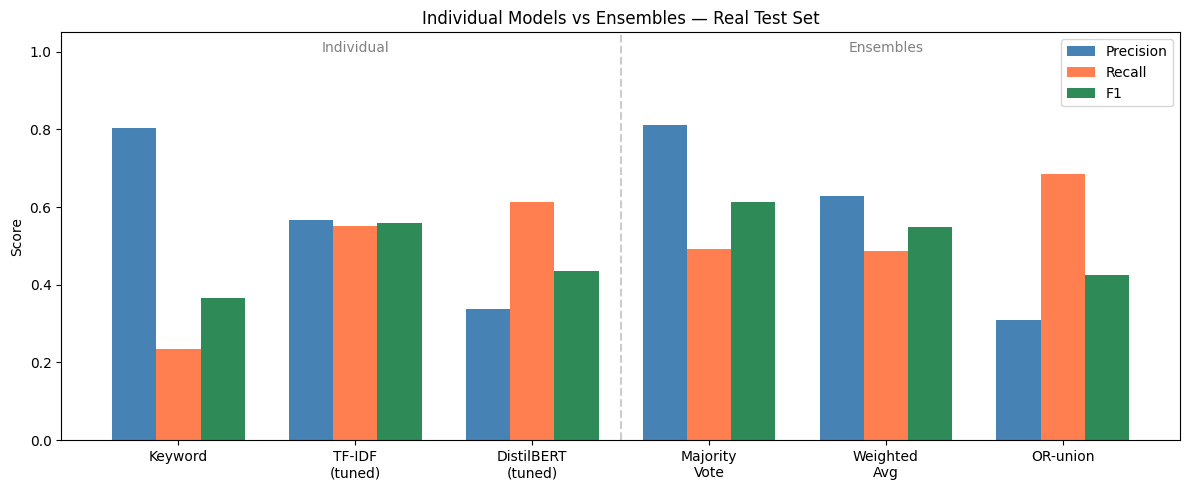

In [131]:
# Ensemble vs individual models — bar chart
ensemble_names = ["Keyword", f"TF-IDF+LR tuned@{thresh_clean:.2f} (clean)",
                  f"DistilBERT tuned@{bert_thresh_clean:.2f} (clean)",
                  "Ensemble: Majority Vote", f"Ensemble: Weighted@{ens_thresh:.2f}", "Ensemble: OR-union"]
ens_results = [next(r for r in all_results if r["Model"] == n and r["Dataset"] == "Real Test") for n in ensemble_names]
short_names = ["Keyword", "TF-IDF\n(tuned)", "DistilBERT\n(tuned)", "Majority\nVote", "Weighted\nAvg", "OR-union"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(short_names))
width = 0.25

ax.bar(x - width, [r["Precision"] for r in ens_results], width, label="Precision", color="steelblue")
ax.bar(x, [r["Recall"] for r in ens_results], width, label="Recall", color="coral")
ax.bar(x + width, [r["F1"] for r in ens_results], width, label="F1", color="seagreen")

ax.set_ylabel("Score")
ax.set_title("Individual Models vs Ensembles — Real Test Set")
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.legend()
ax.set_ylim(0, 1.05)
ax.axvline(2.5, color="gray", linestyle="--", alpha=0.4)
ax.text(1.0, 1.0, "Individual", ha="center", fontsize=10, color="gray")
ax.text(4.0, 1.0, "Ensembles", ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.show()

## 9. Conclusion

### Findings

- **Three approaches** were compared: keyword/regex baseline, TF-IDF + logistic regression, and fine-tuned DistilBERT
- Each learning-based model was trained on both **raw and filler-cleaned** text to measure the effect of preprocessing
- **Mixing real training data** from 8 videos into the synthetic training set helps bridge the synthetic-to-real domain gap — the model sees real Whisper transcription artifacts and genuine ad phrasing during training
- The test set uses 18 held-out videos (split by video to prevent leakage)
- **Ensemble methods** combine the complementary strengths of all three models — keyword precision, TF-IDF statistical recall, and DistilBERT semantic understanding — to improve overall performance beyond any single model

### Limitations

- **Synthetic training data**: LLM-generated text is cleaner and more uniform than real Whisper transcriptions; real data helps but the domain gap remains
- **Class imbalance**: Real data is ~97% non-ad, requiring careful threshold tuning
- **CPU training**: Limited to DistilBERT (66M params) rather than larger models
- **Text-only**: No audio features used (mel spectrograms were a stretch goal)

### Future Work

- Collect more real labeled data from SponsorBlock to further increase real training coverage
- Explore audio-based CNN classifier on mel spectrograms for comparison
- Investigate longer context windows to capture segment-level patterns